In [1]:
!pip install ultralytics roboflow -q

import ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
from roboflow import Roboflow

# ── Get your free API key at https://app.roboflow.com → Settings → API Keys
from google.colab import userdata
API_KEY=userdata.get('roboflow')

rf      = Roboflow(api_key=API_KEY)
project = rf.workspace("roboflow-universe-projects").project("mask-wearing-iskms")
dataset = project.version(5).download("yolov11")

YAML_PATH = dataset.location + "/data.yaml"
print("\nDataset YAML:", YAML_PATH)

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov11 in progress : 85.0%
Version export complete for yolov11 format



Extracting Dataset Version Zip to Mask-Wearing-5 in yolov11:: 100%|██████████| 16956/16956 [00:02<00:00, 6310.00it/s]


Dataset YAML: /content/Mask-Wearing-5/data.yaml


In [3]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
import numpy as np

DATASET_ROOT = Path(dataset.location)
CLASS_NAMES  = ['mask', 'no-mask']
COLORS       = ['#2ecc71', '#e74c3c']   # green / red



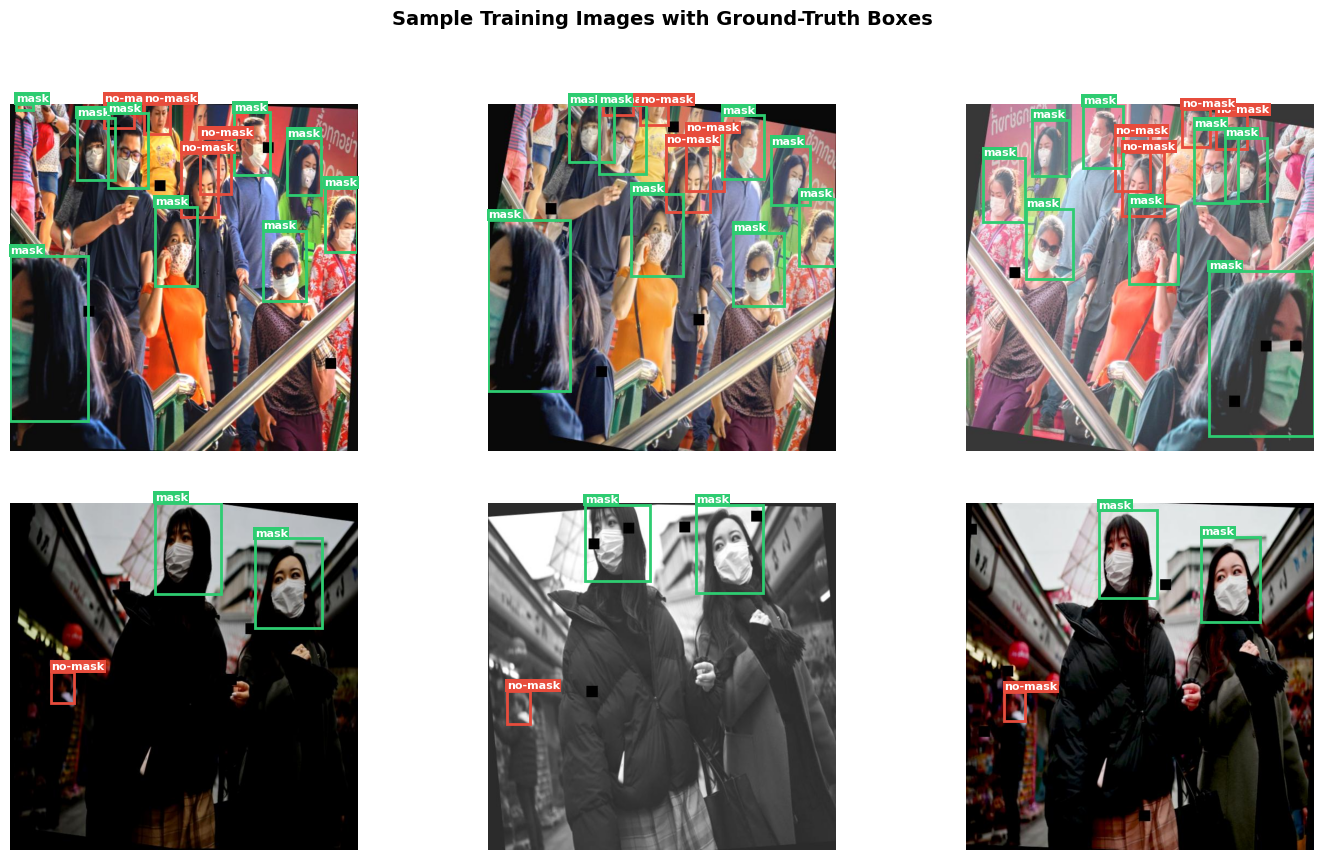

In [4]:
# ── Sample images with ground-truth bounding boxes
train_img_dir = DATASET_ROOT / 'train' / 'images'
train_lbl_dir = DATASET_ROOT / 'train' / 'labels'

sample_imgs = sorted(train_img_dir.glob('*.jpg'))[:6] + sorted(train_img_dir.glob('*.png'))[:6]
sample_imgs = sample_imgs[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_path in zip(axes.flat, sample_imgs):
    img = mpimg.imread(str(img_path))
    h, w = img.shape[:2]
    ax.imshow(img)
    lbl_path = train_lbl_dir / img_path.with_suffix('.txt').name
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            parts  = line.split()
            cls_id = int(parts[0])
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            color = COLORS[cls_id] if cls_id < len(COLORS) else 'blue'
            rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                       linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
            ax.text(x1, y1 - 4, label, color='white', fontsize=8, fontweight='bold',
                    bbox=dict(facecolor=color, pad=1, edgecolor='none'))
    ax.axis('off')

plt.suptitle('Sample Training Images with Ground-Truth Boxes', fontsize=14, fontweight='bold')
plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
from ultralytics import YOLO

# yolo11n (fastest) | yolo11s | yolo11m | yolo11l | yolo11x (most accurate)
model = YOLO('yolo11s.pt')

results = model.train(
    data=YAML_PATH,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,            # GPU; use 'cpu' if no GPU
    workers=2,
    patience=20,         # early stopping
    save=True,
    save_period=10,
    project='/content/runs',
    name='yolo11_mask',
    exist_ok=True,
    plots=True,
    verbose=True,

    # ── Class-imbalance mitigations ───────────────────────────────────────────
    cls=1.2,             # higher classification loss weight
    copy_paste=0.3,      # copy-paste aug — synthesises minority-class instances
    mosaic=1.0,
    mixup=0.1,
    weight_decay=0.0005,
)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.2, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Mask-Wearing-5/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_mask, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, persp

In [ ]:
best_model = YOLO('/content/runs/yolo11_mask/weights/best.pt')

metrics = best_model.val(data=YAML_PATH, split='val')

print('\n── Validation Results ──────────────────────')
print(f'mAP@0.5      : {metrics.box.map50:.4f}')
print(f'mAP@0.5:0.95 : {metrics.box.map:.4f}')
print(f'Precision    : {metrics.box.mp:.4f}')
print(f'Recall       : {metrics.box.mr:.4f}')

In [ ]:
# ── Per-class metrics
import pandas as pd

per_class = pd.DataFrame({
    'Class'    : CLASS_NAMES,
    'Precision': metrics.box.p.tolist(),
    'Recall'   : metrics.box.r.tolist(),
    'mAP@0.5'  : metrics.box.ap50.tolist(),
})
print(per_class.to_string(index=False))

x     = range(len(CLASS_NAMES))
width = 0.25
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - width for i in x], per_class['Precision'], width, label='Precision', color='#42a5f5')
ax.bar([i          for i in x], per_class['Recall'],   width, label='Recall',    color='#66bb6a')
ax.bar([i + width  for i in x], per_class['mAP@0.5'],  width, label='mAP@0.5',  color='#ffa726')
ax.set_xticks(list(x))
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.1)
ax.set_title('Per-Class Metrics — Validation Set', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Training plots (loss curves, PR curve, confusion matrix)
import glob, os

plot_files = sorted(glob.glob('/content/runs/yolo11_mask/*.png'))
n = min(4, len(plot_files))
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1:
    axes = [axes]
for ax, path in zip(axes, plot_files[:n]):
    ax.imshow(mpimg.imread(path))
    ax.set_title(os.path.basename(path), fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
test_metrics = best_model.val(data=YAML_PATH, split='test')

print('\n── Test Results ────────────────────────────')
print(f'mAP@0.5      : {test_metrics.box.map50:.4f}')
print(f'mAP@0.5:0.95 : {test_metrics.box.map:.4f}')
print(f'Precision    : {test_metrics.box.mp:.4f}')
print(f'Recall       : {test_metrics.box.mr:.4f}')

In [ ]:
# ── Visual predictions on test images
test_img_dir = DATASET_ROOT / 'test' / 'images'
test_images  = (sorted(test_img_dir.glob('*.jpg')) +
                sorted(test_img_dir.glob('*.png')))[:6]

preds = best_model.predict(
    source=[str(p) for p in test_images],
    conf=0.25,
    iou=0.45,
    verbose=False
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, result in zip(axes.flat, preds):
    plotted = result.plot()          # BGR numpy array
    ax.imshow(plotted[:, :, ::-1])   # BGR → RGB
    ax.axis('off')

plt.suptitle('YOLO11 Predictions on Test Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7 · Export & download

In [ ]:
# ── ONNX (universal — works with FastAPI, OpenCV, ONNX Runtime)
best_model.export(format='onnx', imgsz=640)
print('ONNX model saved.')

# Uncomment for TensorRT (fastest on NVIDIA GPU):
# best_model.export(format='engine')

In [ ]:
# ── Download weights to local machine
from google.colab import files

files.download('/content/runs/yolo11_mask/weights/best.pt')
files.download('/content/runs/yolo11_mask/weights/best.onnx')